# Entendimiento de opciones 

El escenario: 
- Eres un agricultor que ya sembró 100 toneladas de maíz. 
  - Hoy el precio en el mercado es de $50 USD por tonelada. 
  - Tienes miedo de que el precio colapse a $20 cuando coseches dentro de 3 meses.La solución: 
     - Compras una opción Long Put con un Strike (K) de $48 USD, pagando una prima (p) de $3 USD.

In [2]:
def simular_cobertura_put():
    # Parámetros del mundo real
    precio_actual_activo = 50.0
    K = 48.0   # El "piso" que garantizas para tu venta
    p = 3.0    # El costo del seguro (prima)
    
    # Escenarios de mercado al vencimiento (ST)
    escenarios_precio_final = [20.0, 35.0, 45.0, 48.0, 55.0, 70.0]
    
    print("SIMULACIÓN: COBERTURA CON PROTECTIVE PUT (SEGURO DE PRECIO)")
    print(f"Tienes el activo físico. Compras PUT con Strike = ${K} | Prima = ${p}")
    print("-" * 85)
    print(f"{'Precio Final (ST)':<20}{'Valor Activo Físico':<25}{'Ganancia/Pérdida Put':<25}{'Resultado Neto Total':<20}")
    print("-" * 85)
    
    for ST in escenarios_precio_final:
        # 1. El valor de tu activo físico en el mercado libre
        valor_activo = ST
        
        # 2. La lógica de tu Long Put (El Seguro)
        # Si el mercado cae abajo de 48, ejerces tu derecho a vender a 48.
        payoff_put = max(K - ST, 0)
        profit_put = payoff_put - p
        
        # 3. El resultado combinado (Activo + Put)
        resultado_total = valor_activo + profit_put
        
        print(f"${ST:<19.2f}${valor_activo:<24.2f}${profit_put:<24.2f}${resultado_total:<19.2f}")

simular_cobertura_put()


SIMULACIÓN: COBERTURA CON PROTECTIVE PUT (SEGURO DE PRECIO)
Tienes el activo físico. Compras PUT con Strike = $48.0 | Prima = $3.0
-------------------------------------------------------------------------------------
Precio Final (ST)   Valor Activo Físico      Ganancia/Pérdida Put     Resultado Neto Total
-------------------------------------------------------------------------------------
$20.00              $20.00                   $25.00                   $45.00              
$35.00              $35.00                   $10.00                   $45.00              
$45.00              $45.00                   $0.00                    $45.00              
$48.00              $48.00                   $-3.00                   $45.00              
$55.00              $55.00                   $-3.00                   $52.00              
$70.00              $70.00                   $-3.00                   $67.00              


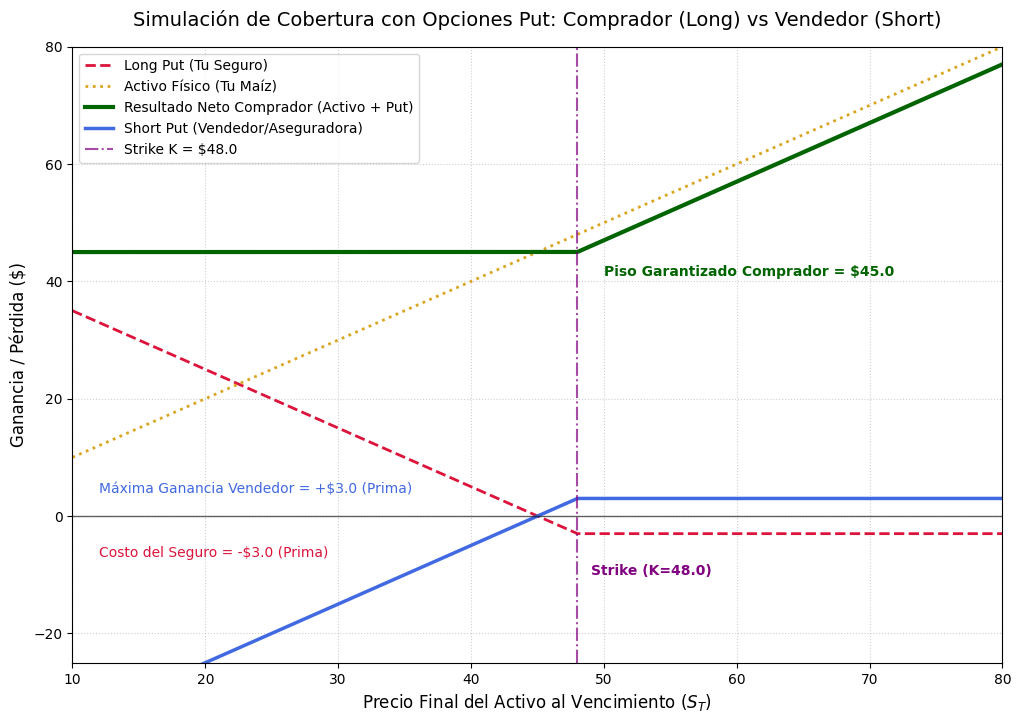

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def graficar_cobertura_put_completa():
    # Parámetros del ejercicio
    K = 48.0   # Precio de ejercicio (Strike)
    p = 3.0    # Prima del Put
    
    # Generamos un rango continuo de precios al vencimiento (ST) de 10 a 80
    ST = np.linspace(10, 80, 500)
    
    # 1. Componentes del COMPRADOR (Long Put + Activo)
    valor_activo = ST
    payoff_long_put = np.maximum(K - ST, 0)
    profit_long_put = payoff_long_put - p
    resultado_neto_comprador = valor_activo + profit_long_put
    
    # 2. Componentes del VENDEDOR (Short Put - Aseguradora)
    # El vendedor NO tiene el activo, solo vende la opción. Su profit es el espejo exacto.
    profit_short_put = p - payoff_long_put

    # Configuración del gráfico
    plt.figure(figsize=(12, 8))
    
    # --- LÍNEAS DEL COMPRADOR (Estrategia Protective Put) ---
    plt.plot(ST, profit_long_put, label='Long Put (Tu Seguro)', color='crimson', linestyle='--', linewidth=2)
    plt.plot(ST, valor_activo, label='Activo Físico (Tu Maíz)', color='goldenrod', linestyle=':', linewidth=2)
    plt.plot(ST, resultado_neto_comprador, label='Resultado Neto Comprador (Activo + Put)', color='darkgreen', linewidth=3)
    
    # --- LÍNEA DEL VENDEDOR (Short Put) ---
    plt.plot(ST, profit_short_put, label='Short Put (Vendedor/Aseguradora)', color='royalblue', linewidth=2.5)
    
    # Líneas de referencia visual
    plt.axhline(0, color='black', linewidth=1, alpha=0.6)  # Línea de ganancia cero
    plt.axvline(K, color='purple', linestyle='-.', alpha=0.7, label=f'Strike K = ${K}') # Línea del Strike
    
    # Anotaciones clave en el gráfico para asimilar el conocimiento
    plt.text(K + 1, -10, f'Strike (K={K})', color='purple', fontweight='bold')
    plt.text(12, p + 1, f'Máxima Ganancia Vendedor = +${p} (Prima)', color='royalblue')
    plt.text(12, -p - 4, f'Costo del Seguro = -${p} (Prima)', color='crimson')
    plt.text(50, 41, f'Piso Garantizado Comprador = ${K-p}', color='darkgreen', fontweight='bold')

    # Etiquetas y diseño
    plt.title('Simulación de Cobertura con Opciones Put: Comprador (Long) vs Vendedor (Short)', fontsize=14, pad=15)
    plt.xlabel('Precio Final del Activo al Vencimiento ($S_T$)', fontsize=12)
    plt.ylabel('Ganancia / Pérdida ($)', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left', fontsize=10)
    
    # Ajustar límites de los ejes para mejor visualización
    plt.xlim(10, 80)
    plt.ylim(-25, 80)
    
    plt.show()

# Ejecutar la función para ver el gráfico interactivo
graficar_cobertura_put_completa()


COMPRADORES VS PERDEDORES 

 ¿ Por qué la ganancia de uno es exactamente la pérdida del otro?
- (Juego de suma cero) y por qué existen las partes "planas".

In [3]:
def juego_de_roles_call():
    K = 50.0  # Strike
    c = 5.0   # Prima
    
    # Precios finales que barren el gráfico de izquierda a derecha
    precios_vencimiento = list(range(35, 71, 5)) 
    
    print("\n=== DUELO DE OPCIONES: LONG CALL vs SHORT CALL ===")
    print(f"Contrato sobre la mesa: Strike (K) = ${K} | Prima (c) = ${c}")
    print("-" * 75)
    print(f"{'Precio Final (ST)':<20}{'Long Call (Comprador)':<28}{'Short Call (Vendedor)':<25}")
    print("-" * 75)
    
    for ST in precios_vencimiento:
        # Comprador
        payoff_long = max(ST - K, 0)
        profit_long = payoff_long - c
        
        # Vendedor (Es exactamente el espejo invertido)
        profit_short = c - payoff_long
        
        # Formatear la explicación visual de la línea "plana"
        status_long = f"${profit_long:.2f} (Plano: Perdió Prima)" if ST <= K else f"${profit_long:.2f} (Sube en diagonal)"
        status_short = f"${profit_short:.2f} (Plano: Ganó Prima)" if ST <= K else f"${profit_short:.2f} (Cae en diagonal)"
        
        print(f"${ST:<19.2f}{status_long:<28}{status_short:<25}")

juego_de_roles_call()



=== DUELO DE OPCIONES: LONG CALL vs SHORT CALL ===
Contrato sobre la mesa: Strike (K) = $50.0 | Prima (c) = $5.0
---------------------------------------------------------------------------
Precio Final (ST)   Long Call (Comprador)       Short Call (Vendedor)    
---------------------------------------------------------------------------
$35.00              $-5.00 (Plano: Perdió Prima)$5.00 (Plano: Ganó Prima)
$40.00              $-5.00 (Plano: Perdió Prima)$5.00 (Plano: Ganó Prima)
$45.00              $-5.00 (Plano: Perdió Prima)$5.00 (Plano: Ganó Prima)
$50.00              $-5.00 (Plano: Perdió Prima)$5.00 (Plano: Ganó Prima)
$55.00              $0.00 (Sube en diagonal)    $0.00 (Cae en diagonal)  
$60.00              $5.00 (Sube en diagonal)    $-5.00 (Cae en diagonal) 
$65.00              $10.00 (Sube en diagonal)   $-10.00 (Cae en diagonal)
$70.00              $15.00 (Sube en diagonal)   $-15.00 (Cae en diagonal)


In [4]:
def comparador_derivados():
    K = 50.0  # Precio pactado para los tres instrumentos
    prima_call = 5.0
    
    precios_vencimiento = [30.0, 40.0, 50.0, 60.0, 70.0]
    
    print("\n=== COMPARATIVA: FORWARD vs FUTURO vs OPCIÓN (CALL) ===")
    print(f"Precio pactado/Strike (K) = ${K} en todos los instrumentos.")
    print("-" * 80)
    print(f"{'Precio Final (ST)':<20}{'Profit Forward':<20}{'Profit Futuro (Neto)*':<23}{'Profit Long Call':<20}")
    print("-" * 80)
    
    for ST in precios_vencimiento:
        # Forward y Futuro comparten el mismo payoff neto final al vencimiento
        profit_forward = ST - K
        profit_futuro = ST - K  # (Ignorando tasas de interés del mark-to-market diario)
        
        # Opción
        profit_call = max(ST - K, 0) - prima_call
        
        print(f"${ST:<19.2f}${profit_forward:<19.2f}${profit_futuro:<22.2f}${profit_call:<19.2f}")
    
    print("-" * 80)
    print("*Nota: El Futuro te hizo liquidar ganancias/pérdidas diariamente paso a paso,")
    print("pero la suma matemática final al vencimiento es equivalente a la del Forward.")

comparador_derivados()



=== COMPARATIVA: FORWARD vs FUTURO vs OPCIÓN (CALL) ===
Precio pactado/Strike (K) = $50.0 en todos los instrumentos.
--------------------------------------------------------------------------------
Precio Final (ST)   Profit Forward      Profit Futuro (Neto)*  Profit Long Call    
--------------------------------------------------------------------------------
$30.00              $-20.00             $-20.00                $-5.00              
$40.00              $-10.00             $-10.00                $-5.00              
$50.00              $0.00               $0.00                  $-5.00              
$60.00              $10.00              $10.00                 $5.00               
$70.00              $20.00              $20.00                 $15.00              
--------------------------------------------------------------------------------
*Nota: El Futuro te hizo liquidar ganancias/pérdidas diariamente paso a paso,
pero la suma matemática final al vencimiento es equivalen